##  **Automatic Image Captioning with Model Benchmarking and Robustness Analysis**
### **Part A: Implementing and Benchmarking a Custom Encoder-Decoder Model**

In this notebook, we delve into the task of automatic image captioning, focusing on implementing and benchmarking a custom encoder-decoder model. Our approach involves the following key steps:

1.  **Custom Model Implementation:** Develop an image captioning model leveraging ViT (Vision Transformer) as the encoder and GPT-2 as the decoder 
2.  **Comparative Analysis:** Evaluate the performance of our custom model against a zero-shot evaluation approach using SmolVLM (Small Vision Language Model)
3.  **Dataset Utilization:** Train and validate our models on a custom dataset.
4.  **Performance Metrics:** Employ standard metrics such as BLEU, METEOR, and ROUGE-L to quantitatively assess the quality of generated captions.

In [ ]:
'''
  Installing dependencies
'''
!pip install nltk
!pip install rouge
!pip install bert-score
!pip install evaluate
!pip install rouge_score


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24935 sha256=cad3b03235d26d64f98b2e55638a34448458458353f574fb30c5031e7a804a1a
  Stored in directory: /root/.cache/pip/wheels/5f/dd/89/461065a73be61a532ff8599a28e9beef17985c9e9c31e541b4
Successfully built rouge_score


In [ ]:
!pip install --upgrade nltk


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 18.8 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: nltk
    Found existing installation: nltk 3.2.4
    Uninstalling nltk-3.2.4:
      Successfully uninstalled nltk-3.2.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
preprocessing 0.1.13 requires nltk==3.2.4, but you have nltk 3.9.1 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
'''
  Importing required packages
'''
import os
import nltk
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import evaluate

from PIL import Image
from torch.utils.data import DataLoader
from transformers import ViTModel, AutoModelForCausalLM, AutoTokenizer, ViTImageProcessor
from transformers import AutoProcessor, AutoModelForVision2Seq
from torch.optim import AdamW
from tqdm import tqdm
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from rouge import Rouge
from bert_score import score

In [ ]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### **Preparing the dataset**

In [ ]:
'''
  CaptionsDataset Class
    This class is used to load the dataset and preprocess the data.
    The images are preprocessed using ViTImageProcessor and the captions are tokenized using AutoTokenizer.

Parameters:
    - csv_file : path to the csv_file containing image filenames and their corresponding captions
    - img_folder : path to the folder containing the images
    - tokenizer : tokenizer to use for processing text captions
    - feature_extractor : feature extractor to use for processing images
    - processor : optional unified processor (can replace separate tokenizer and feature_extractor)
    - max_length : maximum length of the tokenized caption (default: 50)
    - raw_mode : if True, returns raw image paths and captions without preprocessing (default: False)

Returns:
    When raw_mode = False:
    - model_input : dictionary containing the preprocessed image tensors, tokenized caption, attention mask, original caption text, and image path

    When raw_mode = True:
    - tuple of (img_path, caption) with raw data for external processing
'''

class CaptionsDataset(torch.utils.data.Dataset):
    def __init__(self, csv_file, img_folder, tokenizer=None, feature_extractor=None, processor=None, max_length=50, raw_mode=False):
        self.data = pd.read_csv(csv_file)
        self.img_folder = img_folder
        self.feature_extractor = feature_extractor
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.raw_mode = raw_mode

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_folder, self.data.iloc[idx]["filename"])
        caption = self.data.iloc[idx]["caption"]
        image = Image.open(img_path).convert("RGB")
        model_input = {}

        if self.raw_mode:
            return img_path, caption
        else:

            pixel_values = self.feature_extractor(images=image, return_tensors="pt")["pixel_values"].squeeze(0)
            tokenized_caption = self.tokenizer(
                caption,
                padding="max_length",
                truncation=True,
                max_length=self.max_length,
                return_tensors="pt"
            )

            model_input["pixel_values"] = pixel_values
            model_input["input_ids"] = tokenized_caption.input_ids.squeeze(0)
            model_input["attention_mask"] = tokenized_caption.attention_mask.squeeze(0)

        model_input["caption"] = caption
        model_input["img_paths"] = img_path

        return model_input


In [ ]:
'''
  Collate function for PyTorch DataLoader
  This function handles two different data formats:
  1) Raw mode: When batch items are tuples of (img_path, caption)
  2) Training mode: When batch items are dictionaries with processed tensors

  Parameters:
      batch: List of data items to be collated

  Returns:
      Dictionary containing batched data with consistent structure:
      - For raw mode: {'img_paths': [...], 'captions': [...]}
      - For training mode: 
      {
        'pixel_values': tensor, 
        'input_ids': tensor,
        'attention_mask': tensor, 
        'captions': [...], 
        'img_paths': [...]
    }
'''

def collate_fn(batch):
    if isinstance(batch[0], tuple):
        img_paths, captions = zip(*batch)
        return {
            'img_paths': list(img_paths),
            'captions': list(captions)
        }

    # Training mode
    pixel_values = torch.stack([item['pixel_values'] for item in batch])
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])
    captions = [item['caption'] for item in batch]
    img_paths = [item['img_paths'] for item in batch]

    return {
        'pixel_values': pixel_values,
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'captions': captions,
        'img_paths': img_paths
    }


In [ ]:
'''
  Function: get_captioning_loaders
      Creates and returns DataLoaders for training, validation, and testing image captioning models.
      Supports two processing modes:
      1. Raw mode with use_processor=True: Returns raw image paths and captions
      2. Preprocessed mode with use_processor=False: Preprocesses images and tokenizes captions before loading

  Parameters:
      root_dir (str), train_dir (str), val_dir (str), test_dir (str): Directories containing images and captions
      train_csv (str), val_csv (str), test_csv (str): Filenames of CSV files containing captions
      batch_size (int): Number of samples per batch
      collate_fn (callable, optional): Custom collation function for DataLoader
      use_processor (bool): If True, datasets return raw data.
      tokenizer_model_id (str): HuggingFace model ID for tokenizer (default: "gpt2")
      extractor_model_id (str): HuggingFace model ID for image feature extractor (default: "google/vit-base-patch16-224-in21k")

  Returns:
      tuple: (train_loader, val_loader, test_loader) - DataLoaders for training, validation and testing
'''

def get_captioning_loaders(
    root_dir='dataset/custom_captions_dataset',
    train_dir='train',
    val_dir='val',
    test_dir='test',
    train_csv='train.csv',
    val_csv='val.csv',
    test_csv='test.csv',
    batch_size=8,
    collate_fn=None,
    use_processor=False,
    tokenizer_model_id="gpt2",
    extractor_model_id="google/vit-base-patch16-224-in21k"
):

    if use_processor:
        def dataset_factory(csv_file, image_root):
            return CaptionsDataset(
                csv_file=csv_file,
                img_folder=image_root,
                raw_mode=True
            )

    else:
        tokenizer = AutoTokenizer.from_pretrained(tokenizer_model_id)
        feature_extractor = ViTImageProcessor.from_pretrained(extractor_model_id)

        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token

        def dataset_factory(csv_file, image_root):
            return CaptionsDataset(
                csv_file=csv_file,
                img_folder=image_root,
                tokenizer=tokenizer,
                feature_extractor=feature_extractor
            )

    train_path = f"{root_dir}/{train_dir}"
    val_path = f"{root_dir}/{val_dir}"
    test_path = f"{root_dir}/{test_dir}"
    train_csv_path = f"{root_dir}/{train_csv}"
    val_csv_path = f"{root_dir}/{val_csv}"
    test_csv_path = f"{root_dir}/{test_csv}"

    train_dataset = dataset_factory(train_csv_path, train_path)
    val_dataset = dataset_factory(val_csv_path, val_path)
    test_dataset = dataset_factory(test_csv_path, test_path)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    return train_loader, val_loader, test_loader


#### **Captioning using SmolVLM**

In [ ]:
# load the dataloaders and the datasets

train_loader, val_loader, test_loader = get_captioning_loaders(
    root_dir='/kaggle/input/captioning',
    use_processor=True,
    batch_size=1
)

train_dataset = train_loader.dataset
val_dataset = val_loader.dataset
test_dataset = test_loader.dataset

Training Dataset Size   : 5715
Validation Dataset Size : 946
Test Dataset Size       : 928


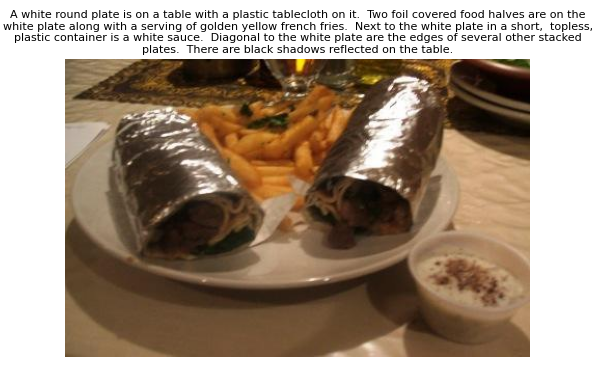

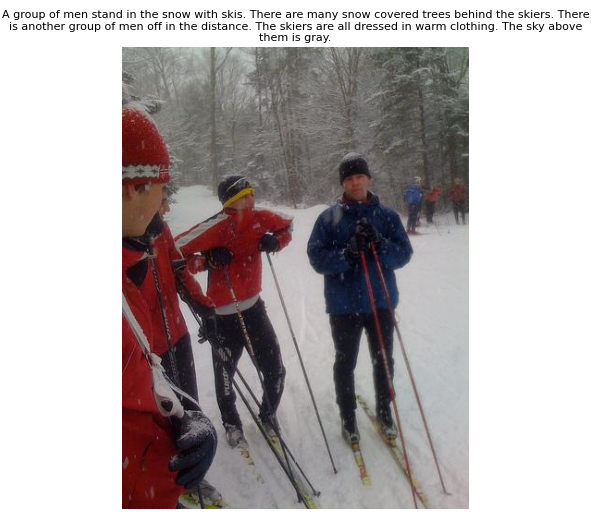

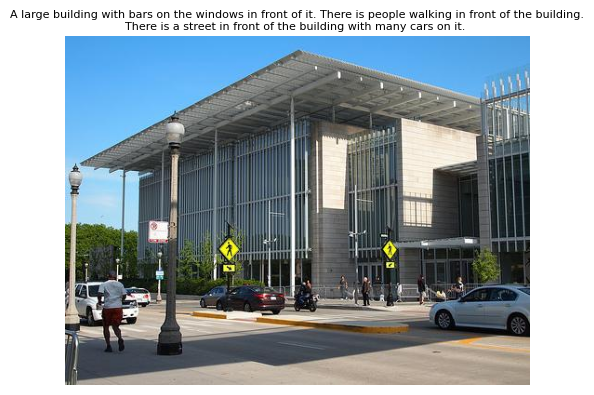

In [ ]:
#use raw_mode to test loaded dataset by displaying few images and the corresponding captions.

def captionized_image(image_path, caption):
    image = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(caption, fontsize=8, wrap=True)
    plt.show()

print(f"Training Dataset Size   : {len(train_dataset)}")
print(f"Validation Dataset Size : {len(val_dataset)}")
print(f"Test Dataset Size       : {len(test_dataset)}")

train_img_path, train_caption = train_dataset[0]
val_img_path, val_caption = val_dataset[0]
test_img_path, test_caption = test_dataset[0]

captionized_image(train_img_path, train_caption)
captionized_image(val_img_path, val_caption)
captionized_image(test_img_path, test_caption)


In [ ]:
'''
  Using huggingface's HuggingFaceTB/SmolVLM-Instruct we get the caption for the given image using the prompt "Generate caption for this image."
  Zero-shot because we do not train the model over our specific database
'''

def zero_shot_captioning(image_path, model_name="HuggingFaceTB/SmolVLM-Instruct") -> str:
    # Set device
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Load processor and model
    processor = AutoProcessor.from_pretrained(model_name)
    processor.tokenizer.padding_side = "left"
    model = AutoModelForVision2Seq.from_pretrained(
        model_name,
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        attn_implementation="eager"
    ).to(device)
    model.eval()

    # Load image
    image = Image.open(image_path).convert("RGB")

    # First, prepare the chat template format without tokenizing
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": "Generate caption for this image."}
            ]
        }
    ]

    # Apply chat template to get the formatted text
    prompt = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
    )

    # Now process the formatted text and image together
    inputs = processor(
        text=prompt,
        images=[image],  # Note: images must be passed as a list
        return_tensors="pt",
        padding=True
    ).to(device)

    # Generate caption
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=200)

    # Decode and return caption
    caption = processor.batch_decode(output, skip_special_tokens=True)[0]
    return caption


In [ ]:
''' generate captions for test dataset '''

hypotheses = []
references = []

total_images = len(test_dataset)
for idx in range(total_images):

    image_path,caption = test_dataset[idx]
    generated_caption = zero_shot_captioning(image_path)
    generated_caption = generated_caption.replace("User:<image>Generate caption for this image.", "").strip()
    generated_caption = generated_caption.replace("Assistant:", "").strip()

    hypotheses.append(generated_caption)
    references.append([caption.split()])



In [ ]:
# save generated captions to our csv file.

df = pd.DataFrame(hypotheses)
output_csv_path = "/kaggle/working/captions-smolVLM.csv"
df.to_csv(output_csv_path, index=False)
print(f"Captions saved to {output_csv_path}")

Captions saved to /kaggle/working/captions-smolVLM.csv


In [ ]:
'''
  NLTK WordNet Setup for Kaggle Environment

  This setup was necessary because Kaggle notebooks have limited persistence and
  downloaded NLTK data needs to be explicitly saved to the working directory
'''

import zipfile
nltk.data.path.append("/kaggle/working/nltk_data")
nltk.download('wordnet', download_dir='/kaggle/working/nltk_data')
nltk.download('omw-1.4', download_dir='/kaggle/working/nltk_data')
zip_path = "/kaggle/working/nltk_data/corpora/wordnet.zip"
extract_to = "nltk_data/corpora"

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("wordnet.zip extracted successfully.")

### Evaluating performance

In [ ]:

'''
Function: performance_metrics
    Calculates and visualizes various evaluation metrics for comparing generated captions (hypotheses)
    with ground truth captions (references).

    The function computes BLEU, ROUGE-L, BERTScore and METEOR

Parameters:
    hypotheses (list): Generated captions
    references (list): Ground truth captions
    csv_path (str): Path to save the per-caption scores

Returns:
    dict: Dictionary containing average scores for all evaluation metrics

Outputs:
    - Saves detailed per-caption scores to a CSV file
    - Displays plots showing the distribution of scores across all captions
    - Prints aggregate metrics
'''

def performance_metrics(hypotheses, references, csv_path="caption_scores.csv"):
    hypotheses = [str(h).strip() if isinstance(h, (str, float)) else "" for h in hypotheses]
    references = [str(r).strip() if isinstance(r, (str, float)) else "" for r in references]

    sentence_bleu_scores = []
    rouge_l_scores = []
    bert_f1_scores = []
    meteor_scores_list = []
    rows = []

    rouge_evaluator = Rouge(metrics=["rouge-l"])
    _, _, bert_f1 = score(hypotheses, references, lang="en", verbose=False)
    bert_f1 = bert_f1.tolist()
    n = len(hypotheses)

    print("\n--- Caption Evaluation ---\n")

    for idx, (hypothesis, reference) in enumerate(zip(hypotheses, references)):
        if not hypothesis or not reference:
            bleu = rouge = meteor = 0
        else:
            bleu = sentence_bleu([reference.split()], hypothesis.split())
            rouge = rouge_evaluator.get_scores([hypothesis], [reference])[0]["rouge-l"]["f"]
            meteor = meteor_score([reference.split()], hypothesis.split())

        sentence_bleu_scores.append(bleu)
        rouge_l_scores.append(rouge)
        meteor_scores_list.append(meteor)

        row = {
            "Index": idx + 1,
            "Hypothesis": hypothesis,
            "Reference": reference,
            "Sentence BLEU": bleu,
            "ROUGE-L F1": rouge,
            "BERTScore F1": bert_f1[idx],
            "METEOR": meteor
        }
        rows.append(row)
        #print(f"[{idx+1}/{n}] BLEU: {bleu:.4f}, ROUGE-L: {rouge:.4f}, BERT: {bert_f1[idx]:.4f}, METEOR: {meteor:.4f}")

    df = pd.DataFrame(rows)
    df.to_csv(csv_path, index=False)

    indices = list(range(len(hypotheses)))
    step = max(len(hypotheses) // 20, 1)
    x_ticks = np.arange(0, len(hypotheses), step)

    fig, axs = plt.subplots(2, 2, figsize=(18, 8))

    axs[0, 0].plot(indices, sentence_bleu_scores, color='skyblue', linewidth=0.8)
    axs[0, 0].set_title("Sentence BLEU Score")
    axs[0, 0].set_xticks(x_ticks)
    axs[0, 0].set_xlabel("Caption Index")
    axs[0, 0].set_ylabel("Score")

    axs[0, 1].plot(indices, rouge_l_scores, color='salmon', linewidth=0.8)
    axs[0, 1].set_title("ROUGE-L F1 Score")
    axs[0, 1].set_xticks(x_ticks)
    axs[0, 1].set_xlabel("Caption Index")

    axs[1, 0].plot(indices, bert_f1, color='lightgreen', linewidth=0.8)
    axs[1, 0].set_title("BERTScore F1")
    axs[1, 0].set_xticks(x_ticks)
    axs[1, 0].set_xlabel("Caption Index")

    axs[1, 1].plot(indices, meteor_scores_list, color='violet', linewidth=0.8)
    axs[1, 1].set_title("METEOR Score")
    axs[1, 1].set_xticks(x_ticks)
    axs[1, 1].set_xlabel("Caption Index")

    plt.tight_layout()
    plt.show()

    results = {
        "Sentence BLEU Score": sum(sentence_bleu_scores) / len(sentence_bleu_scores) if sentence_bleu_scores else 0,
        "Corpus BLEU Score": corpus_bleu([[r.split()] for r in references if r], [c.split() for c in hypotheses if c]) if any(references) else 0,
        "Average ROUGE-L F1": sum(rouge_l_scores) / len(rouge_l_scores) if rouge_l_scores else 0,
        "Average BERTScore F1": sum(bert_f1) / len(bert_f1) if bert_f1 else 0,
        "Average METEOR Score": sum(meteor_scores_list) / len(meteor_scores_list) if meteor_scores_list else 0
    }

    return results

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Caption Evaluation ---



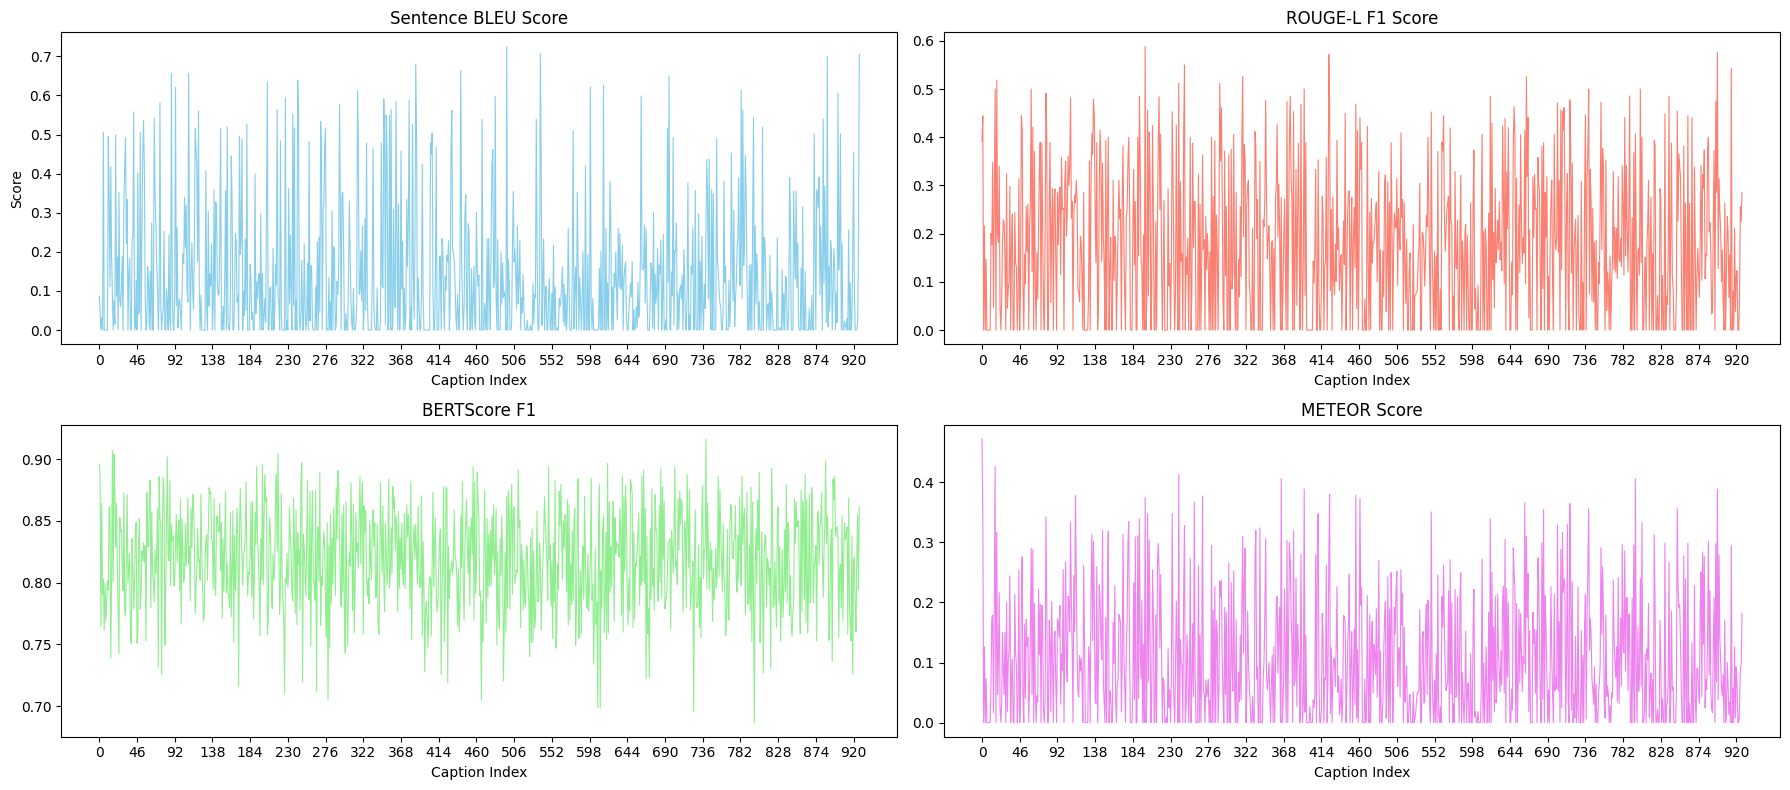

Performance Metrics:
Sentence BLEU Score: 0.1375
Corpus BLEU Score: 0.0227
Average ROUGE-L F1: 0.1755
Average BERTScore F1: 0.8184
Average METEOR Score: 0.1047


In [ ]:
csv_path = 'smolvlm-scores.csv'
metrics = performance_metrics(hypotheses, references, csv_path)
print("Performance Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

#### **Captioning using Custom Model**


In [ ]:
train_loader, val_loader, test_loader = get_captioning_loaders(
    root_dir='/kaggle/input/captioning',
    batch_size=8
)

train_dataset = train_loader.dataset
val_dataset = val_loader.dataset
test_dataset = test_loader.dataset

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

In [ ]:
def compute_metrics(eval_preds, tokenizer):
    metric = evaluate.load("rouge")

    preds, labels = eval_preds

    if isinstance(preds, tuple):
        preds = preds[0]

    decoded_preds = preds

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = ["\n".join(nltk.sent_tokenize(pred)) for pred in decoded_preds]
    decoded_labels = ["\n".join(nltk.sent_tokenize(label)) for label in decoded_labels]

    result = metric.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )

    result = {k: round(v * 100, 4) for k, v in result.items()}

    prediction_lens = [np.count_nonzero(pred != tokenizer.pad_token_id) for pred in preds]
    result["gen_len"] = np.mean(prediction_lens)

    return result

**Custom ImageCaptioningModel Class**

- **Encoder-Decoder Architecture**: Uses ViT as the image encoder and GPT-2 as the text decoder.
- **Feature Projection**: Maps ViT's image features to GPT-2's embedding space using a linear layer.
- **Concatenation of Embeddings**: Combines projected image features with token embeddings for caption generation.
- **Fine-tuning**: Freezes ViT parameters and trains GPT-2 to generate captions.
- **Caption Generation**: Implements a `generate` method for generating captions given an image.
- **Training**: Supports training with a language modeling loss.

In [ ]:
class ImageCaptioningModel(nn.Module):

    '''
    ImageCaptioningModel Class

    Parameters:
        vit_model: Pretrained Vision Transformer model for image feature extraction
        gpt_model: Pretrained GPT model for caption generation
        tokenizer: Tokenizer associated with the GPT model for text processing
    '''

    def __init__(self, vit_model, gpt_model, tokenizer):
        super(ImageCaptioningModel, self).__init__()
        self.vit_model = vit_model
        self.gpt_model = gpt_model
        self.tokenizer = tokenizer
        self.tokenizer.pad_token = self.tokenizer.eos_token

        self.linear_layer = nn.Linear(vit_model.config.hidden_size, gpt_model.config.hidden_size)

        for param in self.vit_model.parameters():
            param.requires_grad = False


    def forward(self, pixel_values, input_ids=None, attention_mask=None, labels=None):
        '''
        Forward pass for training or inference

        Parameters:
            pixel_values: Tensor of preprocessed images [batch_size, channels, height, width]
            input_ids: Token IDs for caption text (for training) [batch_size, seq_length]
            attention_mask: Mask to avoid attention on padding tokens [batch_size, seq_length]
            labels: Labels for computing language modeling loss (optional)

        Returns:
            outputs: Model outputs including loss during training and logits during inference
        '''

        vit_outputs = self.vit_model(pixel_values=pixel_values)
        image_features = vit_outputs.last_hidden_state

        # Using CLS tokens
        cls_features = image_features[:, 0]  # [batch_size, hidden_size]

        # Project to GPT's embedding space
        projected_features = self.linear_layer(cls_features)  # [batch_size, gpt_hidden_size]

        # Reshape for GPT
        prefix_embeds = projected_features.unsqueeze(1)  # [batch_size, 1, gpt_hidden_size]

        #print(f"Prefix Embeds Shape: {prefix_embeds.shape}")
        #print(f"Pixel Values Shape: {pixel_values.shape}")
        #print(f"Input IDs Shape: {input_ids.shape if input_ids is not None else None}")
        #print(f"Attention Mask Shape: {attention_mask.shape if attention_mask is not None else None}")
        #print(f"Labels Shape: {labels.shape if labels is not None else None}")

        # Get GPT embeddings for input tokens
        if input_ids is not None:
            token_embeds = self.gpt_model.transformer.wte(input_ids)

            # Concatenate prefix with token embeddings (prefix embeddings are the embeddings from the ViT)
            inputs_embeds = torch.cat([prefix_embeds, token_embeds], dim=1)

            # Adjust attention mask so that it accounts for the prefix embedding
            if attention_mask is not None:
                batch_size = attention_mask.shape[0]
                prefix_attention_mask = torch.ones((batch_size, 1), device=attention_mask.device)
                full_attention_mask = torch.cat([prefix_attention_mask, attention_mask], dim=1)
            else:
                full_attention_mask = None

            # Preparing labels
            if labels is not None:

                shifted_labels = torch.full(
                    (input_ids.shape[0], input_ids.shape[1] + 1),
                    -100,
                    dtype=torch.long,
                    device=input_ids.device
                )

                shifted_labels[:, 1:] = input_ids.clone()

                # GPT model
                outputs = self.gpt_model(
                    inputs_embeds=inputs_embeds,
                    attention_mask=full_attention_mask,
                    labels=shifted_labels
                )
            else:
                # If no labels provided, just get the output without computing loss
                outputs = self.gpt_model(
                    inputs_embeds=inputs_embeds,
                    attention_mask=full_attention_mask
                )

            return outputs
        else:
            # For generation, just return the projected features
            return prefix_embeds

    def generate(self, pixel_values, max_length=50, num_beams=4, early_stopping=True):
        '''
        Generate captions for input images

        Parameters:
            pixel_values: Tensor of preprocessed images [batch_size, channels, height, width]
            max_length: Maximum length of generated caption
            num_beams: Number of beams for beam search
            early_stopping: Whether to stop when all beams have finished

        Returns:
            captions: List of generated caption strings
        '''
        # Get image embeddings
        with torch.no_grad():
            vit_outputs = self.vit_model(pixel_values=pixel_values)
            image_features = vit_outputs.last_hidden_state
            cls_features = image_features[:, 0]
            projected_features = self.linear_layer(cls_features)
            prefix_embeds = projected_features.unsqueeze(1)

        # Generate caption using GPT with image prefix
        output_ids = self.gpt_model.generate(
            inputs_embeds=prefix_embeds,
            max_length=max_length,
            num_beams=num_beams,
            early_stopping=early_stopping,
            no_repeat_ngram_size=2,
            pad_token_id=self.tokenizer.pad_token_id,
            eos_token_id=self.tokenizer.eos_token_id
        )

        # Decode the generated tokens to text
        captions = [self.tokenizer.decode(output_id, skip_special_tokens=True) for output_id in output_ids]

        return captions

In [ ]:
def train_model(model, train_dataloader, val_dataloader, optimizer, num_epochs, device, eval_every=1):
    '''
    Function: train_model
        Trains and evaluates an image captioning model over multiple epochs.
        Saves the best model

    Parameters:
        model: The image captioning model to train
        train_dataloader
        val_dataloader
        optimizer
        num_epochs: Total number of training epochs
        device: Device to run training on (cuda/cpu)
        eval_every: Frequency of validation in epochs
    '''

    model.to(device)
    best_loss = float('inf')

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}")

        for batch in progress_bar:
            # Move batch to device
            pixel_values = batch['pixel_values'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            # Prepare labels (shifted right by 1)
            labels = input_ids.clone()

            # Forward pass
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            progress_bar.set_postfix({"Loss": loss.item()})

        avg_train_loss = total_loss / len(train_dataloader)
        print(f"Epoch {epoch+1}: Average training loss = {avg_train_loss:.4f}")

        # Evaluate on validation set
        if (epoch + 1) % eval_every == 0:
            val_loss, rouge_scores = evaluate_val(model, val_dataloader, device)
            print(f"Validation loss: {val_loss:.4f}")
            print(f"Rouge scores: {rouge_scores}")

            # Save best model
            if val_loss < best_loss:
                best_loss = val_loss
                torch.save(model.state_dict(), "best_captioning_model.pt")
                print("Model saved!")

In [ ]:
def evaluate_val(model, dataloader, device):
    '''
    Function: evaluate_val
        Evaluates the image captioning model on a validation/test dataset by computing:
        1. Loss on teacher-forced predictions
        2. ROUGE on generated captions

    Parameters:
        model: The image captioning model to evaluate
        dataloader
        device: Device to run evaluation on (cuda/cpu)

    Returns:
        tuple: (average_loss, rouge_scores)
            - average_loss: Mean loss across all evaluation batches
            - rouge_scores: Dictionary of ROUGE metrics for generated captions
    '''

    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            # Move batch to device
            pixel_values = batch['pixel_values'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            # Prepare labels
            labels = input_ids.clone()

            # Forward pass
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            total_loss += loss.item()

            # Generate captions for ROUGE evaluation
            generated_ids = model.generate(pixel_values)

            all_preds.extend(generated_ids)
            all_labels.extend(input_ids.cpu().numpy())

    # Compute ROUGE scores
    rouge_scores = compute_metrics((all_preds, all_labels), model.tokenizer)

    return total_loss / len(dataloader), rouge_scores

In [ ]:
# initialize models from huggingface

vit_model = ViTModel.from_pretrained('google/vit-base-patch16-224-in21k')
gpt_model = AutoModelForCausalLM.from_pretrained("gpt2")

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
# initialize tokenizer and feature extractor, again, from huggingface

tokenizer = AutoTokenizer.from_pretrained("gpt2")
feature_extractor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')

### Training custom model

In [ ]:
# Create model
model = ImageCaptioningModel(vit_model, gpt_model, tokenizer)

# Create optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Train model
train_model(model, train_loader, val_loader, optimizer, num_epochs=5, device=device)

# Test model
test_loss, test_rouge = evaluate_val(model, test_loader, device)
print(f"Test loss: {test_loss:.4f}")
print(f"Test ROUGE scores: {test_rouge}")

Using device: cuda


Epoch 1: 100%|██████████| 715/715 [03:03<00:00,  3.90it/s, Loss=1.73]


Epoch 1: Average training loss = 2.4625


Evaluating: 100%|██████████| 119/119 [02:08<00:00,  1.08s/it]


Validation loss: 2.2643
Rouge scores: {'rouge1': 36.9348, 'rouge2': 10.708, 'rougeL': 26.0418, 'rougeLsum': 34.6871, 'gen_len': 1.0}
Model saved!


...

Epoch 5: Average training loss = 1.7934


Evaluating: 100%|██████████| 119/119 [01:56<00:00,  1.02it/s]


Validation loss: 2.2135
Rouge scores: {'rouge1': 39.5064, 'rouge2': 13.4082, 'rougeL': 28.2619, 'rougeLsum': 37.3552, 'gen_len': 1.0}


Evaluating: 100%|██████████| 116/116 [02:03<00:00,  1.07s/it]


Test loss: 2.2174
Test ROUGE scores: {'rouge1': 40.076, 'rouge2': 13.4837, 'rougeL': 28.3613, 'rougeLsum': 37.7023, 'gen_len': 1.0}


In [ ]:
def generate_caption_for_image(image_path, model, feature_extractor, device):

    '''
    Function: generate_caption_for_image
        Generates a caption for an image using the provided model.

    Parameters:
        image_path
        model
        feature_extractor
        device

    Returns:
        caption: Generated caption for the image
    '''
    image = Image.open(image_path).convert("RGB")
    pixel_values = feature_extractor(images=image, return_tensors="pt").pixel_values.to(device)

    model.to(device)
    model.eval()

    with torch.no_grad():
        captions = model.generate(pixel_values)

    return captions[0]

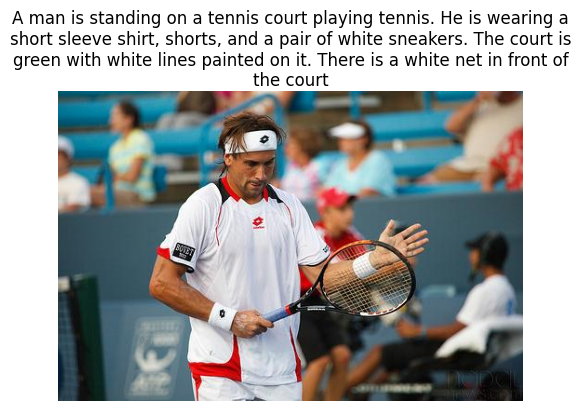

In [ ]:
# Testin model on a single example datapoint

import matplotlib.pyplot as plt
from PIL import Image

def display_image_with_caption(image_path, caption):
    image = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(caption, fontsize=12, wrap=True)
    plt.show()

# Generate caption
sample_image_path = "/kaggle/input/captioning/test/test_30.jpg"
caption = generate_caption_for_image(sample_image_path, model, feature_extractor, device)

# Display image with caption
display_image_with_caption(sample_image_path, caption)


In [ ]:
# generating captions for all test data and storing it in csv file

import os
import pandas as pd
from glob import glob

test_image_folder = "/kaggle/input/captioning/test/"

image_paths = sorted(glob(os.path.join(test_image_folder, "*.jpg")))

results = []
total_images = len(test_dataset)
i = 0
for image_path in image_paths:
    filename = os.path.basename(image_path).split(".")[0]  # Extract filename without extension
    caption = generate_caption_for_image(image_path, model, feature_extractor, device)
    results.append({"Filename": filename, "Caption": caption})
    i+=1

df = pd.DataFrame(results)
output_csv_path = "/kaggle/working/captions-custom.csv"
df.to_csv(output_csv_path, index=False)

print(f"Captions saved to {output_csv_path}")

Captions saved to /kaggle/working/captions-custom.csv


In [ ]:
torch.save(model,"custom_vit_gpt2.pt")

In [ ]:
#Loading the saved output from the trained model to get evaluation metrics
import re
hypotheses_file_path = '/kaggle/input/dl-assignment2/generated_captions_custom.csv'
references_file_path = '/kaggle/input/captioning/test.csv'

df = pd.read_csv(hypotheses_file_path, names=["filename", "caption"], header = None, skiprows = 1)
df["image_num"] = df["filename"].apply(lambda x: int(re.findall(r'\d+', str(x))[0]))
df_sorted = df.sort_values(by="image_num").reset_index(drop=True)
hypotheses = df_sorted["caption"].tolist()

print(len(hypotheses))
print(len(references))
print(hypotheses[0])
print(references[0])

928
928
A large white building is in the background. There is a clock on the front of the building. The clock has black numbers on it. 
A large building with bars on the windows in front of it. There is people walking in front of the building. There is a street in front of the building with many cars on it. 


#### **Calculating Perfomance Metrics for Test Data**

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Caption Evaluation ---



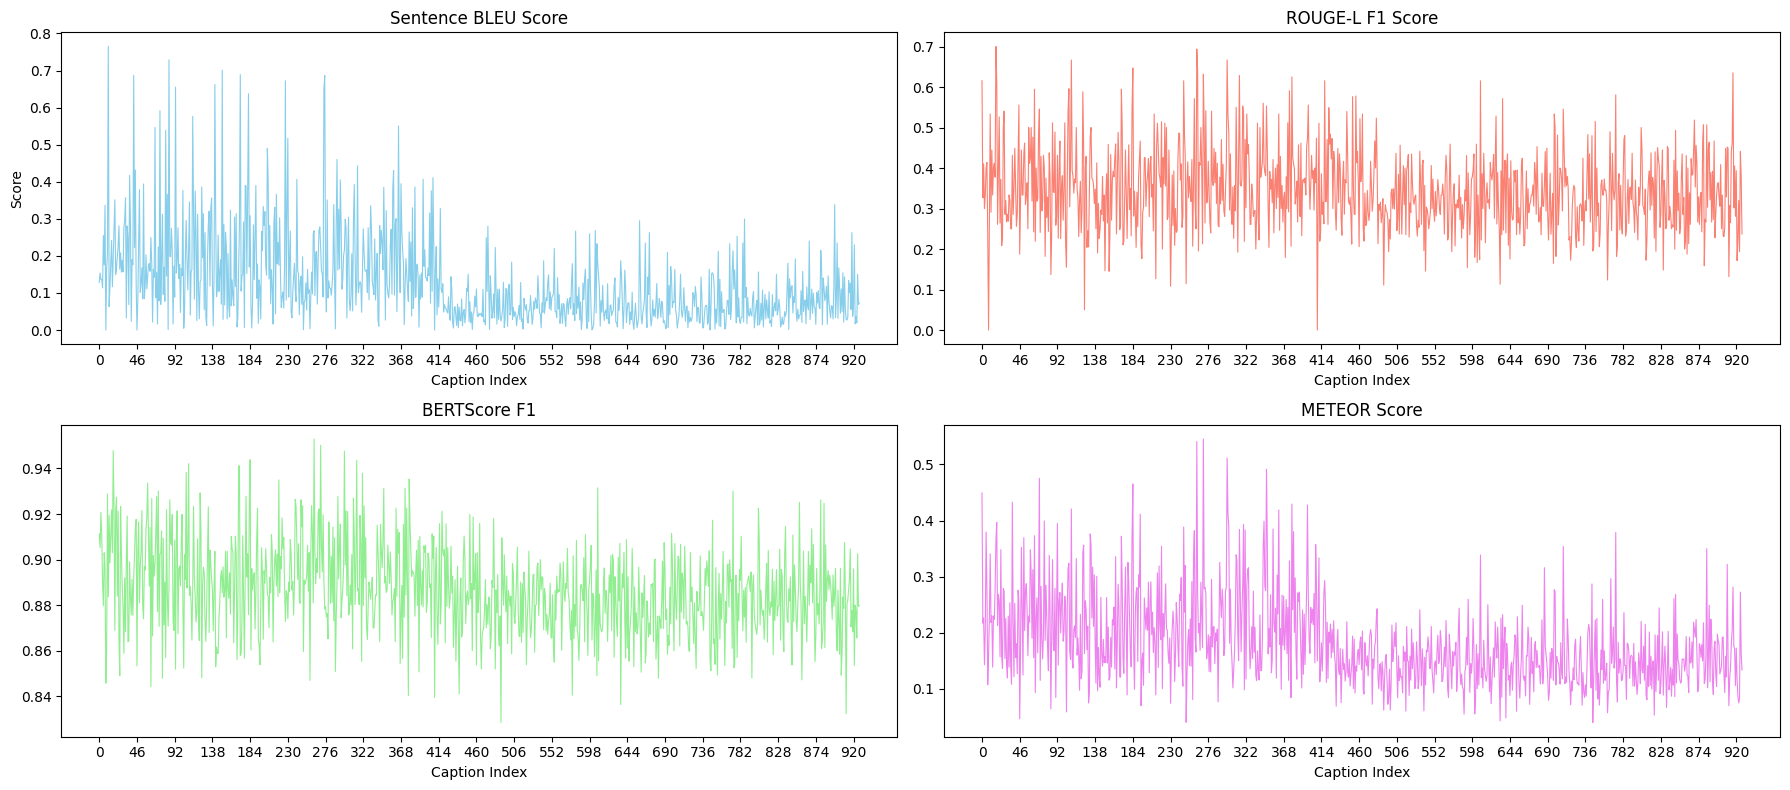

Performance Metrics:
Sentence BLEU Score: 0.1272
Corpus BLEU Score: 0.0307
Average ROUGE-L F1: 0.3447
Average BERTScore F1: 0.8868
Average METEOR Score: 0.1814


In [ ]:
csv_path = 'custom-scores.csv'
metrics = performance_metrics(hypotheses, references, csv_path)
print("Performance Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

#### **Model Evaluation**

In [ ]:
def evaluate_model(model, dataloader, device):
    """
    Evaluate using BLEU, METEOR, and ROUGE-L metrics.

    Args:
        model: The model to evaluate (should have a generate method)
        dataloader: DataLoader with batches containing pixel_values, input_ids,
                    attention_mask, and caption
        device: The device to run evaluation on ('cuda' or 'cpu')

    Returns:
        dict: Dictionary with average BLEU, METEOR, and ROUGE-L scores
    """
    model.eval()
    model.to(device)

    # Initialize metrics
    bleu_scores = []
    meteor_scores = []
    rouge_l_scores = []

    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

    smooth_fn = SmoothingFunction().method1

    total_examples = 0
    successful_evaluations = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            try:
                # Move inputs to device
                pixel_values = batch["pixel_values"].to(device)

                # Generate captions
                predictions = model.generate(pixel_values)

                references = batch["caption"]

                # Process each prediction and reference
                for ref, pred in zip(references, predictions):
                    total_examples += 1

                    try:
                        # Ensure we have string data
                        if isinstance(pred, torch.Tensor):
                            pred = pred.cpu().numpy().tolist()

                        # Convert token IDs to strings if needed
                        if isinstance(pred, list) and (isinstance(pred[0], int) or
                                                      (isinstance(pred[0], np.integer))):
                            # pred = tokenizer.decode(pred, skip_special_tokens=True)
                            pred = " ".join([str(token) for token in pred])

                        # Ensure strings and strip whitespace
                        ref = str(ref).strip()
                        pred = str(pred).strip()

                        # Tokenize
                        ref_tokens = ref.split()
                        pred_tokens = pred.split()

                        # Skip if either reference or prediction is empty
                        if not ref_tokens or not pred_tokens:
                            continue

                        bleu = sentence_bleu(
                            [ref_tokens], pred_tokens, smoothing_function=smooth_fn
                        )
                        bleu_scores.append(bleu)

                        meteor = meteor_score([ref_tokens], pred_tokens)
                        meteor_scores.append(meteor)

                        rouge = scorer.score(ref, pred)["rougeL"].fmeasure
                        rouge_l_scores.append(rouge)

                        successful_evaluations += 1

                    except Exception as e:
                        print(f"Error processing individual prediction: {e}")
                        continue

            except Exception as e:
                print(f"Error processing batch: {e}")
                continue

    # Calculate metrics if we have any successful evaluations
    results = {}
    if successful_evaluations > 0:
        results = {
            "BLEU": sum(bleu_scores) / len(bleu_scores) if bleu_scores else 0.0,
            "METEOR": sum(meteor_scores) / len(meteor_scores) if meteor_scores else 0.0,
            "ROUGE-L": sum(rouge_l_scores) / len(rouge_l_scores) if rouge_l_scores else 0.0,
            "Success_Rate": successful_evaluations / total_examples if total_examples > 0 else 0.0
        }

    print(f"Evaluated {successful_evaluations}/{total_examples} examples successfully")
    return results

In [ ]:
scores = evaluate_model(model,test_loader,device)
print("\nEvaluation Results:")
print(f"BLEU Score    : {scores['BLEU']:.4f}")
print(f"METEOR Score  : {scores['METEOR']:.4f}")
print(f"ROUGE-L Score : {scores['ROUGE-L']:.4f}")

Evaluating: 100%|██████████| 116/116 [01:49<00:00,  1.06it/s]

Evaluated 928/928 examples successfully

Evaluation Results:
BLEU Score    : 0.0311
METEOR Score  : 0.1924
ROUGE-L Score : 0.3115


#### **Loading the same model again (verification to use in Part B)**

In [ ]:
# Step 1: Instantiate your model class
model = ImageCaptioningModel(vit_model, gpt_model, tokenizer)

# Step 2: Load trained weights
state_dict = torch.load('/kaggle/input/vitgptcustom/pytorch/default/1/best_captioning_model.pt')
model.load_state_dict(state_dict)

# Step 3: Move to GPU/CPU and set to eval mode
model.to(device)
model.eval()

<ipython-input-31-402ab0d88202>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('/kaggle/input/vitgptcustom/pytorch/default/1/best_captioning_model.

ImageCaptioningModel(
  (vit_model): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ViTSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_f